<a href="https://www.kaggle.com/code/sonawanelalitsunil/best-games-of-all-time-eda?scriptVersionId=256729982" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/best-games-of-all-time/Best_Games_of_All_Time.csv


## Title :🎮 Best Games of All Time

## Description:
From timeless classics to modern masterpieces, the best games of all time represent the perfect blend of creativity, storytelling, innovation, and player experience. These games have not only redefined the industry but also shaped generations of gamers. From the pixelated charm of retro titles to the immersive open worlds of today, they offer unforgettable adventures, emotional journeys, and groundbreaking gameplay mechanics. Celebrated across genres—whether action, strategy, role-playing, or simulation—these iconic games stand as milestones in gaming history, proving that video games are more than just entertainment; they are cultural phenomena that connect millions worldwide.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/best-games-of-all-time/Best_Games_of_All_Time.csv")

In [3]:
df.head()

,Unnamed: 0,Name,Launch_date,Rating,Metascore,Details
0,0,The Legend of Zelda: Ocarina of Time,"Nov 23, 1998",E,99.0,"As a young boy, Link is tricked by Ganondorf, ..."
1,1,SoulCalibur,"Sep 8, 1999",T,98.0,"This is a tale of souls and swords, transcendi..."
2,2,Grand Theft Auto IV,"Apr 29, 2008",M,98.0,[Metacritic's 2008 Xbox 360 Game of the Year; ...
3,3,Super Mario Galaxy,"Nov 12, 2007",E,97.0,[Metacritic's 2007 Wii Game of the Year] The u...
4,4,Super Mario Galaxy 2,"May 23, 2010",E,97.0,"Super Mario Galaxy 2, the sequel to the galaxy..."


In [4]:
df.tail()

,Unnamed: 0,Name,Launch_date,Rating,Metascore,Details
13829,13829,Vroom in the Night Sky,"Apr 5, 2017",E,17.0,Vroom in the night sky is a magical bike actio...
13830,13830,Yaris,"Oct 10, 2007",E10+,17.0,[Xbox Live Arcade] Hop into a Toyota Yaris an...
13831,13831,Family Party: 30 Great Games Obstacle Arcade,"Dec 4, 2012",NaN,11.0,Family Party: 30 Great Games Obstacle Arcade b...
13832,13832,The Rogue Prince of Persia,"Aug 31, 2025",NaN,NaN,Jump into this action roguelite installment in...
13833,13833,Stormgate,"Aug 5, 2025",NaN,NaN,Earth didn't stand a chance. Our story begins ...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13834 entries, 0 to 13833
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   13834 non-null  int64  
 1   Name         13834 non-null  object 
 2   Launch_date  13834 non-null  object 
 3   Rating       11585 non-null  object 
 4   Metascore    13832 non-null  float64
 5   Details      13809 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 648.6+ KB


In [6]:
df.describe()

,Unnamed: 0,Metascore
count,13834.000000,13832.000000
mean,6916.500000,70.528774
std,3993.676147,12.284368
min,0.000000,11.000000
25%,3458.250000,64.000000
50%,6916.500000,72.000000
75%,10374.750000,79.000000
max,13833.000000,99.000000


In [7]:
df.isnull().sum()

Unnamed: 0        0
Name              0
Launch_date       0
Rating         2249
Metascore         2
Details          25
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Unnamed: 0       int64
Name            object
Launch_date     object
Rating          object
Metascore      float64
Details         object
dtype: object

In [10]:
df.shape

(13834, 6)

In [11]:
df.columns

Index(['Unnamed: 0', 'Name', 'Launch_date', 'Rating', 'Metascore', 'Details'], dtype='object')

## Data visualizations

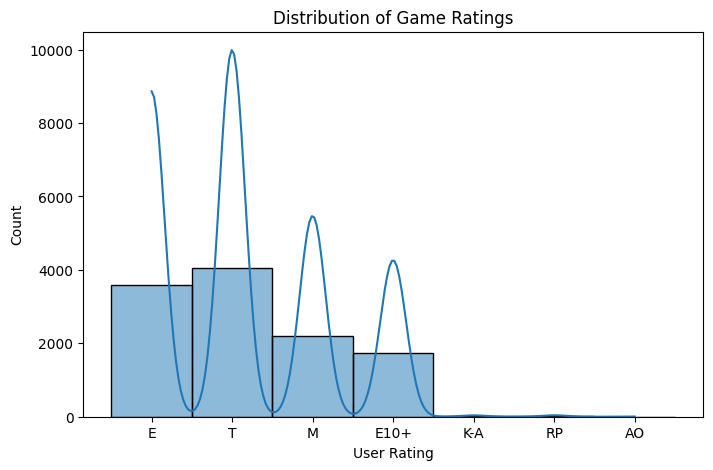

In [12]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['Launch_date'] = pd.to_datetime(df['Launch_date'], errors='coerce')
df['Year'] = df['Launch_date'].dt.year
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Distribution of Game Ratings")
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.show()

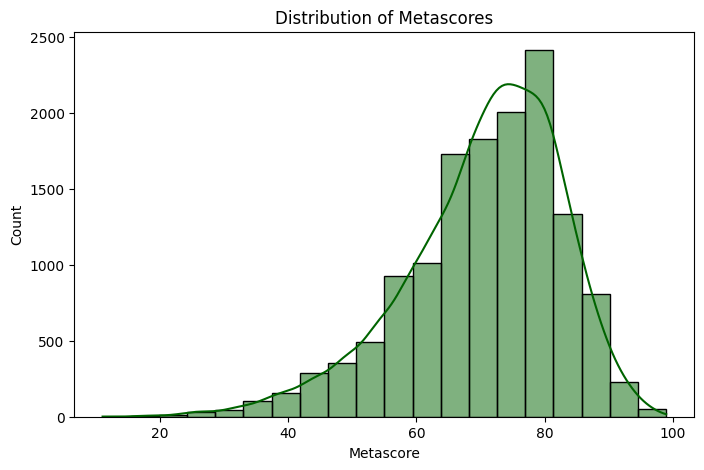

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Metascore'], bins=20, kde=True, color="darkgreen")
plt.title("Distribution of Metascores")
plt.xlabel("Metascore")
plt.ylabel("Count")
plt.show()

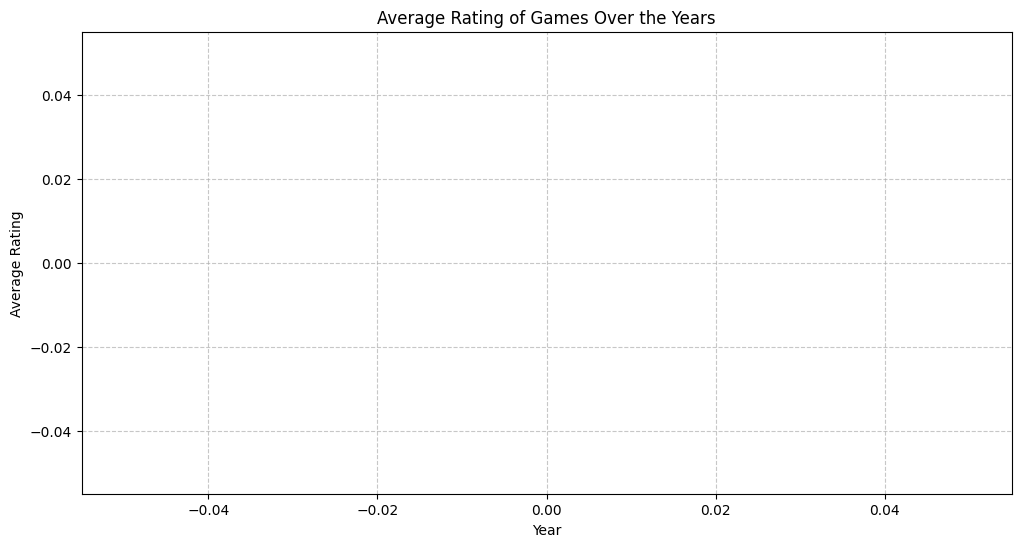

In [14]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Metascore column as well (if stored as string)
df['Metascore'] = pd.to_numeric(df['Metascore'], errors='coerce')

# Now groupby works
avg_rating_year = df.groupby("Year")["Rating"].mean().dropna()

plt.figure(figsize=(12,6))
avg_rating_year.plot(marker="o")
plt.title("Average Rating of Games Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

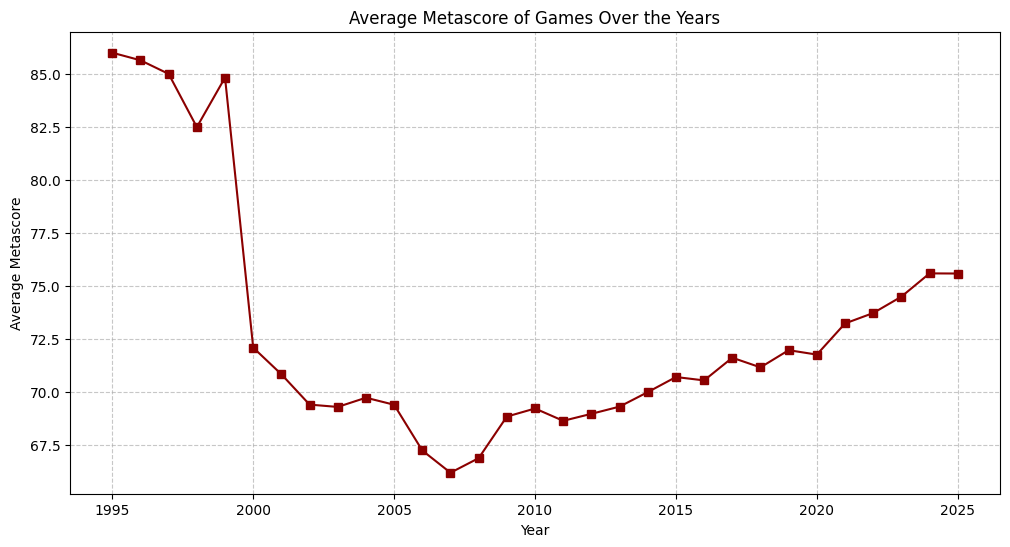

In [15]:
avg_metascore_year = df.groupby("Year")["Metascore"].mean().dropna()

plt.figure(figsize=(12,6))
avg_metascore_year.plot(marker="s", color="darkred")
plt.title("Average Metascore of Games Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Metascore")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Thank you...pls upvote!!!